In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# TASK 1:- Data Loading & Exploration

## first 5,000 rows only

## Load the CSV file using Pandas

In [3]:
df = pd.read_csv("Reviews.csv").head(5000)

In [4]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
4995,4996,B00653KJ5M,AGE64SY3HP9RV,CZ,1,1,2,1341273600,The cavemen must have been wealthy,I really wanted to like these.<br /><br />Firs...
4996,4997,B00653KJ5M,A1MPEPNJ2NKWM,Rachel Albert Matesz,1,1,1,1341100800,These cookies need work; you can make your own...,I was not impressed with these cookies when I ...
4997,4998,B00653KJ5M,A1T6I625FGQS20,IL,1,1,3,1336694400,Okay in a pinch - not great,The cookies came sealed and seem to be high qu...
4998,4999,B00653KJ5M,A3POAWC2JPQQQP,me,0,0,4,1342137600,"they are good (except for the ""rainforest"" fla...","These taste very good, but aren't like the BES..."


## Display the first 10 rows

In [5]:
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


## Check how many rows and columns are there

In [6]:
df.shape

(5000, 10)

## Identify which column contains the review text

In [7]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


# task 2 :- Data Cleaning

## Remove rows where the review text is empty or null

In [8]:
df = df.dropna(subset=['Text'])

## Remove duplicate reviews

In [9]:
df = df.drop_duplicates(subset=['Text'])

## Keep only the columns you need: review text + rating (score)

In [10]:
df = df[['Text', 'Score']] 

In [11]:
print(df.columns)

Index(['Text', 'Score'], dtype='object')


## Task 3 :- Sentiment Analysis

## Install and use the TextBlob library (pip install textblob)

In [12]:
from textblob import TextBlob

TextBlob("Test").sentiment

Sentiment(polarity=0.0, subjectivity=0.0)

## For each review, calculate the sentiment polarity score

In [13]:
from textblob import TextBlob

df['Polarity'] = df['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

df.head()

,Text,Score,Polarity
0,I have bought several of the Vitality canned d...,5,0.450000
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333
2,This is a confection that has been around a fe...,4,0.133571
3,If you are looking for the secret ingredient i...,2,0.166667
4,Great taffy at a great price. There was a wid...,5,0.483333


## Based on the score, label each review as:
## Positive → score > 0
## Negative → score < 0
## Neutral → score = 0


In [14]:
def classify_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Polarity'].apply(classify_sentiment)

In [15]:
df[['Text', 'Polarity', 'Sentiment']].head()

,Text,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,-0.033333,Negative
2,This is a confection that has been around a fe...,0.133571,Positive
3,If you are looking for the secret ingredient i...,0.166667,Positive
4,Great taffy at a great price. There was a wid...,0.483333,Positive


In [16]:
df['Sentiment'].value_counts()

Sentiment
Positive    4403
Negative     501
Neutral       80
Name: count, dtype: int64

## Task 4 — Visualization

## Chart 1: Bar chart showing count of Positive, Negative, and Neutral reviews

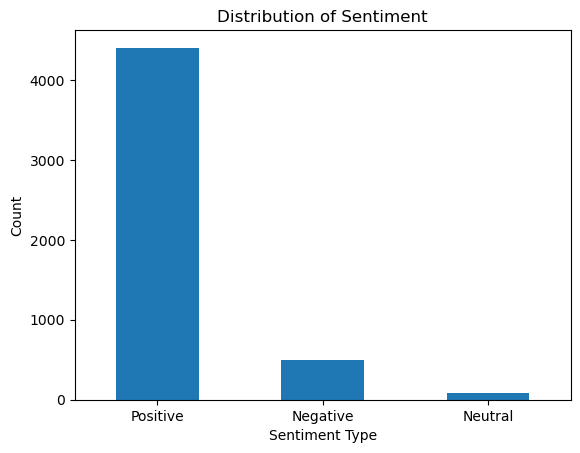

In [20]:
df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Distribution of Sentiment")
plt.xlabel("Sentiment Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.savefig("charts/bar_chart.png", dpi=300)
plt.show()

## Chart 2: Pie chart showing the percentage distribution of sentiments

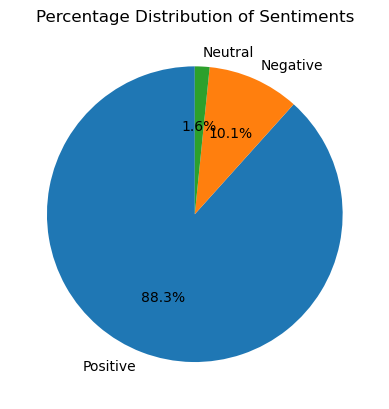

In [21]:
df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage Distribution of Sentiments")
plt.ylabel("")

plt.savefig("charts/Pie_chart.png", dpi=300)
plt.show()

## Chart 3: A chart of your own choice — be creative!

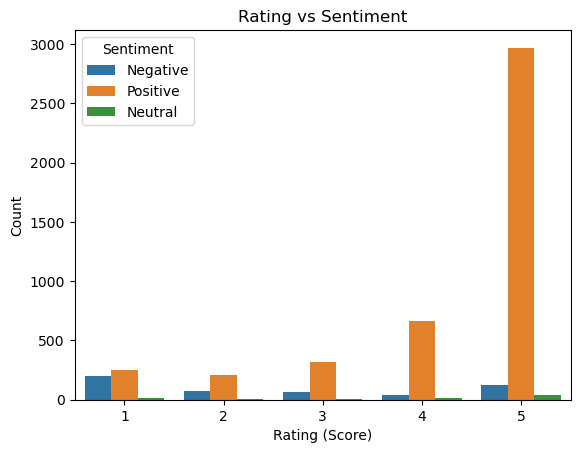

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Score', hue='Sentiment', data=df)

plt.title("Rating vs Sentiment")
plt.xlabel("Rating (Score)")
plt.ylabel("Count")

plt.savefig("charts/rating_vs_sentiment.png", dpi=300)
plt.show()